In [1]:
from time import time
import mininumpy as mnp
import random
import matplotlib.pyplot as plt



In [2]:
n = [2, 3, 4, 5, 6, 7]
n_gau = [150, 200, 250, 300, 350, 400]

# Build test matrices
tests = [
    [mnp.Array([[random.random() for _ in range(N)] for _ in range(N)]) for N in n],
    [mnp.Array([[random.random() for _ in range(N)] for _ in range(N)]) for N in n_gau]
]


det = {}
timer = {}
times = 3

for algo in ['laplace', 'LU', 'gaussian']:

    det[algo] = []
    timer[algo] = []

    # choose the correct test size group
    if algo == 'laplace':
        dataset = tests[0]      # small matrices
    else:
        dataset = tests[1]      # large matrices

    for i in range(len(dataset)):
        delta_t = 0
        for t in range(times):
            start = time()
            d = mnp.minilinalg.det(dataset[i], algo=algo)
            stop = time()
            delta_t += stop - start

        det[algo].append(d)
        timer[algo].append(delta_t / times)



In [ ]:
print(timer)

{'laplace': [4.482269287109375e-05, 3.528594970703125e-05, 0.00012493133544921875, 0.0006401538848876953, 0.0061571598052978516, 0.03049945831298828], 'LU': [2.662119150161743, 6.156489372253418, 12.0710928440094, 21.26948595046997, 36.55783700942993, 57.625330448150635], 'gaussian': [2.7178845405578613, 5.303051710128784, 10.492797374725342, 18.921833515167236, 28.68571949005127, 47.85148572921753]}


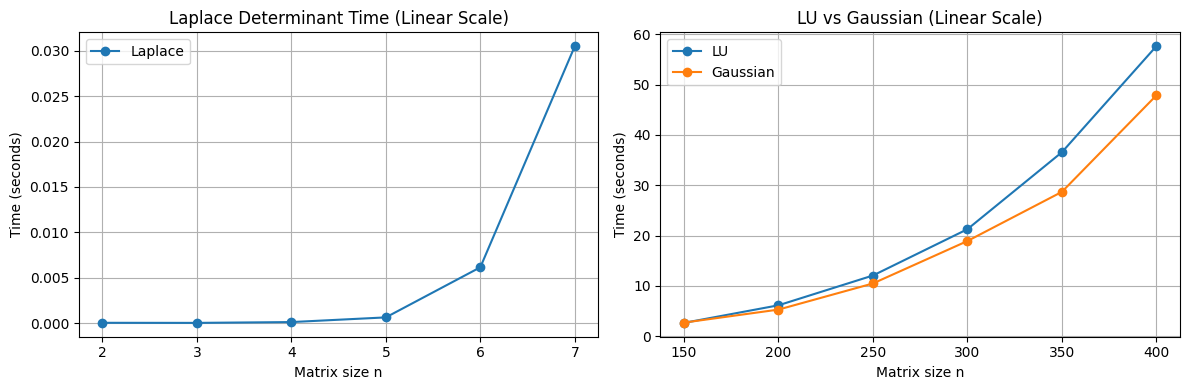

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# --- LEFT: Laplace alone ---
axes[0].plot(n, timer["laplace"], marker="o", label="Laplace")
axes[0].set_title("Laplace Determinant Time (Linear Scale)")
axes[0].set_xlabel("Matrix size n")
axes[0].set_ylabel("Time (seconds)")
axes[0].grid(True)
axes[0].legend()

# --- RIGHT: LU + Gaussian ---
axes[1].plot(n_gau, timer["LU"], marker="o", label="LU")
axes[1].plot(n_gau, timer["gaussian"], marker="o", label="Gaussian")
axes[1].set_title("LU vs Gaussian (Linear Scale)")
axes[1].set_xlabel("Matrix size n")
axes[1].set_ylabel("Time (seconds)")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()




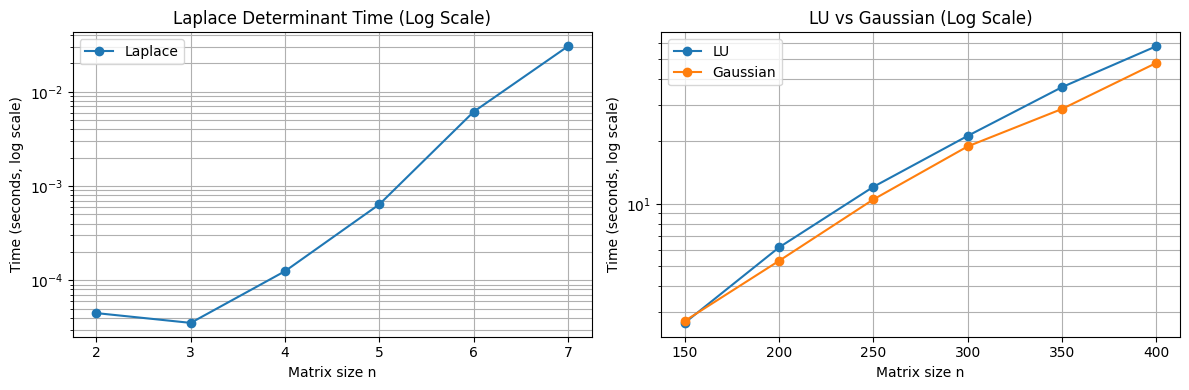

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# --- LEFT: Laplace alone (log scale) ---
axes[0].plot(n, timer["laplace"], marker="o", label="Laplace")
axes[0].set_yscale("log")
axes[0].set_title("Laplace Determinant Time (Log Scale)")
axes[0].set_xlabel("Matrix size n")
axes[0].set_ylabel("Time (seconds, log scale)")
axes[0].grid(True, which="both")
axes[0].legend()

# --- RIGHT: LU + Gaussian (log scale) ---
axes[1].plot(n_gau, timer["LU"], marker="o", label="LU")
axes[1].plot(n_gau, timer["gaussian"], marker="o", label="Gaussian")
axes[1].set_yscale("log")
axes[1].set_title("LU vs Gaussian (Log Scale)")
axes[1].set_xlabel("Matrix size n")
axes[1].set_ylabel("Time (seconds, log scale)")
axes[1].grid(True, which="both")
axes[1].legend()

plt.tight_layout()
plt.show()